<a href="https://colab.research.google.com/github/nhatminhdoan221/SC1003-PROJECT/blob/main/SC1003_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC1003 Mini Project #




## Introduction ##

**Done by:**
1. (hiden)
2. (hiden)
3. Doan Nhat Minh (NHATMINH004@e.ntu.edu.sg)
4. (hiden)
5. (hiden)



overall flowchart.svg

## Read CSV ##

### Read CSV Function ###

The cell below would read the CSV file "records.csv" and generate a dictionary storing the information of all 6000 students using their student ID as the key

<details>
  <summary>Pseudocode:</summary>

```
STRING data_csv = READ records.csv

INITIALIZE data_dict as empty dictionary

FOR line in data_csv
  REMOVE last character // last character is line break

  LIST info_list = SPLIT line at "," // creating a list containing student info

  DICTIONARY info_dict = {"Tutorial Group": info_list[0],
                 "School": info_list[2],
                 "Name": info_list[3],
                 "Gender": info_list[4],
                 "CGPA": float(info_list[5]),
                 "Team Assigned": None
                 "CGPA Band": None}

  data_dict[info_list[1]] = info_dict // data_dict is created with student id as key and info_dict as value

```

</details>


In [ ]:
data_csv = open("records.csv", "r")

data_csv.readline() # Seek to past first line as headers are on first line

data_dict = {}

for line_str in data_csv:
    line_str = line_str[:-1] # Remove line break at end of string

    info_list = line_str.split(",")
    info_dict = {"Tutorial Group": info_list[0],
                 "School": info_list[2],
                 "Name": info_list[3],
                 "Gender": info_list[4],
                 "CGPA": float(info_list[5]),
                 "Team Assigned": None,
                 "CGPA Band": None}

    data_dict[info_list[1]] = info_dict # data_dict is created with student id as key and info_dict as value

print(data_dict)

{'5002': {'Tutorial Group': 'G-1', 'School': 'CCDS', 'Name': 'Aarav Singh', 'Gender': 'Male', 'CGPA': 4.02, 'Team Assigned': None, 'CGPA Band': None}, '3838': {'Tutorial Group': 'G-1', 'School': 'EEE', 'Name': 'Aarti Nair', 'Gender': 'Female', 'CGPA': 4.05, 'Team Assigned': None, 'CGPA Band': None}, '2091': {'Tutorial Group': 'G-1', 'School': 'EEE', 'Name': 'Adlan Bin Rahman', 'Gender': 'Male', 'CGPA': 4.2, 'Team Assigned': None, 'CGPA Band': None}, '288': {'Tutorial Group': 'G-1', 'School': 'CoB (NBS)', 'Name': 'Ajay Verma', 'Gender': 'Male', 'CGPA': 4.01, 'Team Assigned': None, 'CGPA Band': None}, '4479': {'Tutorial Group': 'G-1', 'School': 'CCDS', 'Name': 'Amelia Kim', 'Gender': 'Female', 'CGPA': 4.11, 'Team Assigned': None, 'CGPA Band': None}, '5708': {'Tutorial Group': 'G-1', 'School': 'SoH', 'Name': 'Ananya Ramesh', 'Gender': 'Male', 'CGPA': 4.2, 'Team Assigned': None, 'CGPA Band': None}, '4563': {'Tutorial Group': 'G-1', 'School': 'WKW SCI', 'Name': 'Anjali Patel', 'Gender': 'Fe

### Helper function to group students by tutorial group ###

The cell below creates a list of dictionaries, where every item in the list is a dictionary containing all the students from one tutorial group.

`  [{'student id':{info},'student id':{info}...(TG1 Students)...}, {..(TG2 Student)..}]`

This is useful for decomposing the problem as teams have to be generated within the same tutorial group.

<details>
  <summary>Pseudocode:</summary>


```
FUNCTION group_by_tg(data_dict):
  INITIALISE list_of_tutorial_groups as empty list

  FOR student in data_dict
    IF student["Tutorial Group"] NOT in list_of_tutorial_groups
      ADD student["Tutorial Group"] to list_of_tutorial_groups

  INITIALISE grouped_list as empty list

  FOR group_number in list_of_tutorial_groups
    INITIALISE students_in_group as empty dictionary
    
    FOR student in data_dict
      IF student["Tutorial Group"] == group_number
        ADD student to students_in_group
    
    ADD students_in_group to grouped_list

  RETURN grouped_list  
    
```


</details>

In [ ]:
def group_by_tg(data_dict):

    list_of_tutorial_groups = []

    for student in data_dict.values(): # for every student in data_dict, check if their tutorial group is in the list
        if student["Tutorial Group"] not in list_of_tutorial_groups: # if its in the list skip to next one, if its not, add it to list then skip to next one
            list_of_tutorial_groups.append(student["Tutorial Group"]) # Generate list of tutorial group numbers

    grouped_list = []

    for group_number in list_of_tutorial_groups:
        students_in_group = {}                   # creates a dictionary for each student in tg

        for id , student in data_dict.items(): # iterate through all students
            if student["Tutorial Group"] == group_number: # if the TG number coincides with the current TG number
                students_in_group[id] = data_dict[id] # add the student to the TG dict.

        grouped_list.append(students_in_group)

    return grouped_list

print(group_by_tg(data_dict))

[{'5002': {'Tutorial Group': 'G-1', 'School': 'CCDS', 'Name': 'Aarav Singh', 'Gender': 'Male', 'CGPA': 4.02, 'Team Assigned': None, 'CGPA Band': None}, '3838': {'Tutorial Group': 'G-1', 'School': 'EEE', 'Name': 'Aarti Nair', 'Gender': 'Female', 'CGPA': 4.05, 'Team Assigned': None, 'CGPA Band': None}, '2091': {'Tutorial Group': 'G-1', 'School': 'EEE', 'Name': 'Adlan Bin Rahman', 'Gender': 'Male', 'CGPA': 4.2, 'Team Assigned': None, 'CGPA Band': None}, '288': {'Tutorial Group': 'G-1', 'School': 'CoB (NBS)', 'Name': 'Ajay Verma', 'Gender': 'Male', 'CGPA': 4.01, 'Team Assigned': None, 'CGPA Band': None}, '4479': {'Tutorial Group': 'G-1', 'School': 'CCDS', 'Name': 'Amelia Kim', 'Gender': 'Female', 'CGPA': 4.11, 'Team Assigned': None, 'CGPA Band': None}, '5708': {'Tutorial Group': 'G-1', 'School': 'SoH', 'Name': 'Ananya Ramesh', 'Gender': 'Male', 'CGPA': 4.2, 'Team Assigned': None, 'CGPA Band': None}, '4563': {'Tutorial Group': 'G-1', 'School': 'WKW SCI', 'Name': 'Anjali Patel', 'Gender': 'F

## Teams sorted by Gender and GPA (Explanation and PseudoCode) ##

Aim is to form 10 balanced teams of 5 from each tutorial group (containing 50 students). First students in a tutorial group are separated into male and female lists. Then these male and female lists are further split into 3 groups based on the CGPA bands of the students.
Then the number of males that should be in each of the ten teams is calculated. Any remaining students are assigned evenly across the first few teams. To ensure CGPA diversity in a team I have used a repeating pattern, taking students from high, low then medium bands. When one band runs out, students are taken from the next closest band. Once males are filled, the remaining spots are filled with female students using the same pattern. This ensure fair mix of gender and academic diversity amongst groups.

#Deciding how many males go into each team

    

    FOR each tutorialGroup IN group_by_tg(data_dict):

    tg_name = tutorialGroup[any student]["Tutorial Group"]

    # Separate students by gender
    males   = list of student IDs where Gender == "Male"
    females = list of student IDs where Gender == "Female"

    # Split by CGPA level
    (male_low, male_med, male_high) = split_by_gpa(males, tutorialGroup)
    (female_low, female_med, female_high) = split_by_gpa(females, tutorialGroup)

    # Decide number of males in each of 10 teams
    malesingroup = empty list
    FOR i FROM 1 TO 10:
        IF i ≤ (number of males MOD 10):
            malesingroup.ADD((number of males DIV 10) + 1)
        ELSE:
            malesingroup.ADD(number of males DIV 10)


#Assigning males to teams    

Assign males to teams based on calculated distribution

    FOR i FROM 1 TO 10:

    team_key = "Team " + i
    numberofmales = malesingroup[i]

    FOR j FROM 0 TO numberofmales - 1:

        # Alternate selection between high, low, and medium CGPA
        IF j % 3 == 0 AND male_high NOT EMPTY:
            student_id = male_high.POP_FIRST()
        ELSE IF j % 3 == 1 AND male_low NOT EMPTY:
            student_id = male_low.POP_FIRST()
        ELSE IF male_med NOT EMPTY:
            student_id = male_med.POP_FIRST()
        ELSE:
             # Fallback if one band is empty
             student_id = next available from any non-empty male list

        data_dict[student_id]["Team Assigned"] = i


#Assigning females to fill the remaining spots  

Fill remaining spots (total 5 members per team)

    remaining_spots = 5 - numberofmales

    FOR k FROM 0 TO remaining_spots - 1:

    # Alternate selection between high, low, and medium CGPA
    IF k % 3 == 0 AND female_high NOT EMPTY:
        student_id = female_high.POP_FIRST()
    ELSE IF k % 3 == 1 AND female_low NOT EMPTY:
        student_id = female_low.POP_FIRST()
    ELSE IF female_med NOT EMPTY:
        student_id = female_med.POP_FIRST()
    ELSE:
        # Fallback if one band is empty
        student_id = next available from any non-empty female list

    data_dict[student_id]["Team Assigned"] = i



In [ ]:
def split_by_gpa(ids , data):

    ids.sort(key=lambda id: data[id]["CGPA"]) #sorts list of tuples by cgpa - lowest first highest last

    size = len(ids)                                #find total number of students
    low_gpa = ids[:size//3]                        #first third (lowest gpa)
    mid_gpa = ids[size//3:2* size//3]              #middle third
    high_gpa = ids[2*size//3:]                     #last third (highest gpa)

    for id in low_gpa:  # Assigns CGPA Band value
      data[id]["CGPA Band"] = 3
    for id in mid_gpa:
      data[id]["CGPA Band"] = 2
    for id in high_gpa:
      data[id]["CGPA Band"] = 1

    return low_gpa,mid_gpa,high_gpa                       # Returns 3 lists eaching containing students of lower third, middle third and upper third in CGPA respectively

In [ ]:
for tutorialGroup in group_by_tg(data_dict):                                                                  #grouped list = [{'student id':{info},'student id':{info}...(TG1 Students)...}, {..(TG2 Student)..}], tutorial groups is just a dictionary of students in that tg {'student id':{info},'student id':{info}...(TG1 Students)...}
    tg_name = list(tutorialGroup.values())[0]["Tutorial Group"]                                     #extracts tutorial group number from one of the students in the tutorial group dictionary

    # Splits all the students in a tutorial group into 2 lists depending on whether they are male or female. the 2 lists only contains the ids of the male and female students
    males = [id for id, student in tutorialGroup.items() if student["Gender"] == "Male"]
    females = [id for id, student in tutorialGroup.items() if student["Gender"] == "Female"]

    #splits the males list into 3 different lists based on their cgpa
    male_low , male_med , male_high = split_by_gpa(males , tutorialGroup)

    # splits the females list into 3 different lists based on their cgpa
    female_low , female_med , female_high = split_by_gpa(females , tutorialGroup)

    malesingroup = []       #malesingroup is a list that tells you how many males are supposed to be in each group, this is calculated based on the total number of males in the class, any additional/remainder males are added into the first few groups
    for i in range(1, 11):
        if i <= (len(males) % 10):
            malesingroup.append((len(males) // 10) + 1)
        else:
            malesingroup.append(len(males) // 10)


    for i, numberofmales in enumerate(malesingroup, 1): # creates team key, starting from 1
        team_key = f"Team {i}"

        for j in range(numberofmales):
            if j % 3 == 0 and male_high:
                student_id = male_high.pop(0)
            elif j % 3 == 1 and male_low:
                student_id = male_low.pop(0)
            elif male_med:
                student_id = male_med.pop(0)
            else:
                # Fallback if one band is empty
                if male_high:
                    student_id = male_high.pop(0)
                elif male_low:
                    student_id = male_low.pop(0)
                elif male_med:
                    student_id = male_med.pop(0)
                else:
                    break
            data_dict[student_id]["Team Assigned"]=i #Assign team number to data_dict

        for k in range(5 - numberofmales):
            if k % 3 == 0 and female_high:
                student_id = female_high.pop(0)
            elif k % 3 == 1 and female_low:
                student_id = female_low.pop(0)
            elif female_med:
                student_id = female_med.pop(0)
            else:
                # Fallback if one band is empty
                if female_high:
                    student_id = female_high.pop(0)
                elif female_low:
                    student_id = female_low.pop(0)
                elif female_med:
                    student_id = female_med.pop(0)
                else:
                    break
            data_dict[student_id]["Team Assigned"]=i #Assign team number to data_dict


            # The j % 3 cycle creates a repeating pattern: 0, 1, 2, 0, 1, 2...
            # For each male student being assigned (j = 0, 1, 2, 3...):
            # - j % 3 = 0 → take from high CGPA band (top third of sorted males)
            # - j % 3 = 1 → take from low CGPA band (bottom third of sorted males)
            # - j % 3 = 2 → take from medium CGPA band (middle third of sorted males)
            # This ensures each team gets a diverse mix of high, low, and medium CGPA students
            # in the order: High, Low, Medium, High, Low, Medium...

## Sort by school ##

To ensure a diverse distribution of schools the students are from, we have created a scoring system that measures school diversity and a swapping algorithm to swap players from different teams if it improves the school diverity score.

To maintain the gender and GPA diversity created earlier, we will narrow down the potential students that a student can be swapped with to those of the same gender and same CGPA band.

After a swap is performed, the algorithm will check the new teams for any possible swaps that will improve diversity score again, checking until no more swaps can be found.

---

Flowchart:

Untitled Diagram.svg

### Generate Pairings ###
Helper function to find all possible students a student can swap with from the same gender to preserve gender ratio, and from the same CGPA band to preserve CGPA diverisity

Input `data` is a dictionary containing all the students in the tutorial group that can be generated by `group_by_tg(data_dict)`. The function will return a dictionary where the keys are the individual student IDs, and the values are a list of IDs that student ID can swap with.

<details>
  <summary>Pseudocode:</summary>

```
FUNCTION findPartners(data)
  INTIALIZE pairs as empty dictionary

  FOR student in data:
    INTIALIZE list_of_partners as empty list

    FOR student_partner in data:
      IF student != student partner
        IF student[Gender] == student partner[Gender]
          IF student[CGPA Band] == student partner[CGPA Band]
            ADD student_partner to list_of_partners
    ADD [student:list_of_partners] to pairs

  return pairs
```

</details>


In [ ]:
def findPartners(data):
    pairs = {}
    for id_main , student_main in data.items():
        list_of_partners = []

        for id_partner , student_partner in data.items():
            if (
                id_main != id_partner
                and student_main["Gender"] == student_partner["Gender"]
                and student_main["CGPA Band"] == student_partner["CGPA Band"]
                ): # Possible to write additional filters later
                list_of_partners.append(id_partner)

        pairs[id_main] = list_of_partners

    return pairs # Returns a dictionary where key is student ID and value is dictionary containing list of IDs that student can swap with

### Scoring ###
Score is calculated by dividing the number of unique schools in the team by the total number of people in the team.

Finding the number of unique items can be done by using the Python function `set()` which takes a list and returns a list with only unique items.

Input for the function is a list of student IDs of students from the team, and the dictionary containing the students information, so we can check which school they are from. Function should return a numerical value.

<details>
  <summary>Pseudocode:</summary>

```
FUNCTION school_diveristy(team_ids , data)

  INITIALISE schools as empty list

  FOR student in team_ids:
    ADD student[School] to schools
  
  REMOVE duplicate items from schools

  return (number of items in schools)/(number of items in team_ids)
```

</details>

In [ ]:
def school_diversity(team_ids, data):
    schools = [data[sid]["School"] for sid in team_ids]  #fetches student's school from data_dict based on their student id(sid) and stores them in list called schools
    return len(set(schools)) / len(team_ids)                   #set(schools) creates a set containing only the unique schools from the list, with this proportion of unique schools/total school is calculated
#school score closest to one = greater diversity

### Do swaps ###
First, we have to write a function to check if 2 students from different teams should be swapped. They should only be swapped if the average of the school diversity score improves after the swap as compared to the score before. Therefore, `checkSwapSchool()` takes in the IDs of the students to be swapped and the dictionary contaning their information, and returns a boolean value depending on whether score improves.

<details>
  <summary>Pseudocode:</summary>

```
FUNCTION checkswapschool(id1 , id2 , data)

  INITIALISE team1 as empty list
  INITIALISE team2 as empty list

  FOR student in data:
    IF student[team] == id1[team]
      ADD student to team1

  FOR student in data:
    IF student[team] == id2[team]
      ADD student to team2

  CALCULATE currentscore = (school_diverity(team1) + school_diverity(team2)) /2

  SWAP id1 and id2 from team1 and team2

  CALCULATE newscore = (school_diverity(team1) + school_diverity(team2)) /2

  IF newscore >= currentscore
    RETURN False
  else:
    RETURN True
```

</details>

In [ ]:
def checkSwapSchool(id1 , id2 , data):
    #First generate the 2 teams from the 2 IDs
    team1 = [id for id, student in data.items() if student["Team Assigned"] == data[id1]["Team Assigned"]]
    team2 = [id for id, student in data.items() if student["Team Assigned"] == data[id2]["Team Assigned"]]

    #Calculate school diversity score
    currentscore =  (school_diversity(team1,data) + school_diversity(team2,data))/2

    #Swap students
    indexid1 = team1.index(id1)
    indexid2 = team2.index(id2)

    team1[indexid1] , team2[indexid2] = team2[indexid2] , team1[indexid1]

    #Calculate score again
    newscore =  (school_diversity(team1,data) + school_diversity(team2,data))/2

    #If old score is better, return false and vice versa
    if currentscore >= newscore:
        return False
    else:
        return True


Next, we have to write the recursive function. For every student in the tutorial group, we will check if swapping them with the any of the people that they could possibly swap with would improve the score. Therefore, the function will have 2 inputs, the dictionary containing everyone in a tutorial group from `group_by_tg(data_dict)` and the dictionary containing the list of students a student can swap with.

We will also check if students are from the same team here, and if they are, we will not check if they can be swapped but instead skip to the next possible pair. Doing this check here instead of when we generated pairings means the pairings do not have to be created again after a swap has been performed.

The function will not return any value as the swapping is done in place, and the new team values are updated to the dictionary created by `group_by_tg(data_dict)`, which will then also be passed to `data_dict` as both are pointing to the same location in memory.

If a swap is found, we will then also need to search for swaps again, until no more possible swaps can be found, which is easiest to do with recursion.

<details>
  <summary>Pseudocode:</summary>

```
FUNCTION searchSwapSchool(data , pairs)

  INITIALISE swap_found as False

  FOR student , partners in pairs // Key:Value
    FOR partner in partners //partners is a list
      IF student[Team] == partner[Team]
        CONTINUE
      ELIF checkswapschool(student , partner , data) == True:
        swap_found = True
        swap = (student , partner)
        BREAK
      
    IF swap_found = True:
      BREAK

  IF swap_founf = True:
    SWAP swap[0] with swap[1] // Do in place
    searchSwapSchool(data , pairs) // Seach again recursively

```

</details>

In [ ]:
def searchSwapSchool(data , pairs):
    swap_found = False
    for id , partners in pairs.items():
        for partner in partners:
            if data[id]["Team Assigned"] == data[partner]["Team Assigned"]: #Don't swap within team
                continue
            elif checkSwapSchool(id , partner , tutorialGroup): #Check if swap will improve score
                swap_found = True
                swap = (id,partner) #Store IDs to swap as a tuple
                break
            else:
                continue
        if swap_found:
            break

    if swap_found:
        #Swap IDs
        data[swap[0]]["Team Assigned"] , data[swap[1]]["Team Assigned"] = data[swap[1]]["Team Assigned"] , data[swap[0]]["Team Assigned"]
        #Search for swaps again recursively
        searchSwapSchool(data,pairs)
    else:
        return

In [ ]:
for tutorialGroup in group_by_tg(data_dict):
    pairs = findPartners(tutorialGroup)
    searchSwapSchool(tutorialGroup , pairs)

## Sort by CGPA ##

Similar process to sorting by schools

### Calculate SD ###
Function for calculating Standard deviation

<details>
  <summary>Pseudocode:</summary>
  
 ```
  FUNCTION calculateSD(input_list):
    SET list_length = length of input_list
    IF list_length IS 0 THEN
        RETURN 0
    END IF
    SET mean = SUM of all elements in input_list / list_length

    SET summed_squared_differences = 0

    FOR EACH element 'i' IN input_list:
        SET difference = element 'i' - mean
        SET squared_difference = difference * difference
        SET summed_squared_differences = summed_squared_differences + squared_difference
    END FOR

    SET variance = summed_squared_differences / list_length

    SET SD = SQUARE_ROOT(variance)

    RETURN SD
  END FUNCTION

```
</details>

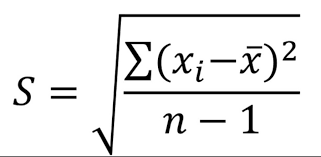

In [ ]:
def calculateSD(input): # Calculate standard deviation, input is list of integers
    mean = sum(input) / len(input)

    squared_differences = []
    for i in input:
        squared_differences.append((i-mean)**2)

    summed_differences = float(sum(squared_differences))

    SD = (summed_differences/len(input)) ** 0.5

    return SD
print(calculateSD([6,3,2,1]))

1.8708286933869707


### Generate Pairings ###
Similar to the process of swapping school previously, we first creat a list of possible students each student can swap. But for this case, we add an additional clause which is the school must be the same since we have already swapped for schools to ensure the diversity scores for schools will not be affected

<details>
  <summary>Pseudocode:</summary>
  
 ```
FUNCTION findPartners_CGPA(data):
    SET pairs = EMPTY DICTIONARY

    FOR EACH id_main, student_main IN data:
        SET list_of_partners = EMPTY LIST

        FOR EACH id_partner, student_partner IN data:
            IF id_main IS NOT EQUAL TO id_partner AND
               student_main["Gender"] IS EQUAL TO student_partner["Gender"] AND
               student_main["CGPA Band"] IS EQUAL TO student_partner["CGPA Band"] AND
               student_main["School"] IS EQUAL TO student_partner["School"] THEN

                ADD id_partner TO list_of_partners
            END IF
        END FOR

        SET pairs[id_main] = list_of_partners
    END FOR

    RETURN pairs
END FUNCTION
```
</details>

Input data is a dictionary containing all the students in the tutorial group that can be generated by group_by_tg(data_dict). The function will return a dictionary where the keys are the individual student IDs, and the values are a list of IDs that student ID can swap with

In [ ]:
def findPartners_CGPA(data):
    pairs = {}
    for id_main , student_main in data.items():
        list_of_partners = []

        for id_partner , student_partner in data.items():
            if (
                id_main != id_partner
                and student_main["Gender"] == student_partner["Gender"]
                and student_main["CGPA Band"] == student_partner["CGPA Band"]
                and student_main["School"] == student_partner["School"]
                ): # Possible to write additional filters later
                list_of_partners.append(id_partner)

        pairs[id_main] = list_of_partners

    return pairs # Returns a dictionary where key is student ID and value is dictionary containing list of IDs that student can swap with

### CGPA diversity score ###

For CGPA diversity score, we calcalate the standard deviation of team divided by the difference between mean of team and mean of class.

We want the spread within the team to be larger as possible to make sure the CGPA spread is diverse while the aboslute difference between mean of team and mean of class is as small as possible, ensuring every team has a similar every CGPA. So for our overall score we can ensure both better spread within the group while maintaining mean cgpa to be close to class average.

We have to add 0.01 to the difference before dividing standard deviation by it to avoid zero division error.
<details>
  <summary>Pseudocode:</summary>
  
 ```
FUNCTION calculate_Diversity_Score(team_ids, data):
    // Data Extraction (Assuming team_ids and data are valid)
    SET class_ids = KEYS of data
    SET class_length = LENGTH of class_ids
    SET team_length = LENGTH of team_ids

    IF class_length IS 0 OR team_length IS 0 THEN
        RETURN 0
    END IF

    // Extract CGPAs for the team and the entire class
    SET team_cgpas = EMPTY LIST
    FOR EACH id IN team_ids:
        ADD data[id]["CGPA"] TO team_cgpas
    END FOR

    SET class_gpas = EMPTY LIST
    FOR EACH id IN class_ids:
        ADD data[id]["CGPA"] TO class_gpas
    END FOR

    // Calculate Metrics
    SET team_sd = CALL calculateSD(team_cgpas)
    SET class_avg = SUM of class_gpas / class_length
    SET team_avg = SUM of team_cgpas / team_length

    // Calculate Difference
    SET diff = ABSOLUTE VALUE OF (team_avg - class_avg)

    // Calculate Overall Score, handling Division by Zero
    SET overall_score = team_sd / (diff+0.01)

    RETURN overall_score
END FUNCTION

```
</details>

In [ ]:
def CGPA_diversity(team_ids , data):
    team_cgpas = [data[id]["CGPA"] for id in team_ids]
    tg_gpas = [data[id]["CGPA"] for id in data.keys()]

    team_sd = calculateSD(team_cgpas)
    team_avg = sum(team_cgpas)/len(team_cgpas)
    tg_avg = sum(tg_gpas)/len(tg_gpas)

    diff = abs(team_avg - tg_avg) #Avoid negative scores

    overall_score = team_sd/(diff+0.01)

    return overall_score

### Checkswap ###

We want to ensure the swap is beneficial in helping both teams in bring their average closer to the class average. This function will return a boolean value(True-->swap is beneficial) VS (False-->swap is not beneficial)
<details>
  <summary>Pseudocode:</summary>
  
```
FUNCTION checkSwap_cgpa(id1, id2, data):
    // Generate the two initial teams based on their current assignment
    SET team_assigned_1 = data[id1]["Team Assigned"]
    SET team_assigned_2 = data[id2]["Team Assigned"]

    SET team1 = [id FOR id IN KEYS of data IF data[id]["Team Assigned"] IS EQUAL TO team_assigned_1]
    SET team2 = [id FOR id IN KEYS of data IF data[id]["Team Assigned"] IS EQUAL TO team_assigned_2]

    // Calculate the current average CGPA diversity score
    SET score1 = CGPA_diversity(team1, data)
    SET score2 = CGPA_diversity(team2, data)
    SET currentscore = (score1 + score2) / 2

    // Locate students in their respective team lists
    SET index_id1 = FIND INDEX of id1 IN team1
    SET index_id2 = FIND INDEX of id2 IN team2

    // Perform the hypothetical swap
    SET team1[index_id1] = id2
    SET team2[index_id2] = id1

    // Calculate the new average CGPA diversity score
    SET new_score1 = CGPA_diversity(team1, data)
    SET new_score2 = CGPA_diversity(team2, data)
    SET newscore = (new_score1 + new_score2) / 2

    // Check if the swap improves the score (higher score is better)
    IF newscore IS GREATER THAN currentscore THEN
        RETURN TRUE
    ELSE
        RETURN FALSE
    END IF
END FUNCTION

```
</details>

In [ ]:
def checkSwap_cgpa(id1 , id2 , data):
    #First generate the 2 teams from the 2 IDs
    team1 = [id for id, student in data.items() if student["Team Assigned"] == data[id1]["Team Assigned"]]
    team2 = [id for id, student in data.items() if student["Team Assigned"] == data[id2]["Team Assigned"]]

    #Calculate cgpa diversity score
    currentscore =  (CGPA_diversity(team1,data) + CGPA_diversity(team2,data))/2

    #Swap students
    indexid1 = team1.index(id1)
    indexid2 = team2.index(id2)

    team1[indexid1] , team2[indexid2] = team2[indexid2] , team1[indexid1]

    #Calculate score again
    newscore =  (CGPA_diversity(team1,data) + CGPA_diversity(team2,data))/2

    #If old score is better, return false and vice versa
    if currentscore >= newscore:
        return False
    else:
        return True

### Do swap ###

Write the recursive function for swapping, if checkswap return True, carry out the swap else leave the current team selection
<details>
  <summary>Pseudocode:</summary>
  
```
FUNCTION searchSwapCGPA(data, pairs):
    SET swap_found = FALSE
    SET swap_id1 = NULL
    SET swap_id2 = NULL

    FOR EACH id, partners_list IN pairs:
        FOR EACH partner IN partners_list:
            IF data[id]["Team Assigned"] IS EQUAL TO data[partner]["Team Assigned"] THEN
                CONTINUE
            END IF

            // Assuming 'data' is passed to checkSwap_cgpa (the original code had 'tutorialGroup')
            IF checkSwap_cgpa(id, partner, data) IS TRUE THEN
                SET swap_found = TRUE
                SET swap_id1 = id
                SET swap_id2 = partner
                BREAK
            END IF
        END FOR

        IF swap_found IS TRUE THEN
            BREAK
        END IF
    END FOR

    IF swap_found IS TRUE THEN
        // Perform the swap on the data structure
        SET team_id_temp = data[swap_id1]["Team Assigned"]
        SET data[swap_id1]["Team Assigned"] = data[swap_id2]["Team Assigned"]
        SET data[swap_id2]["Team Assigned"] = team_id_temp

        // Recursive call to continue searching for further improvements
        CALL searchSwapCGPA(data, pairs)
    ELSE
        RETURN
    END IF
END FUNCTION

```
</details>

In [ ]:
def searchSwapCGPA(data , pairs):
    swap_found = False
    for id , partners in pairs.items():
        for partner in partners:
            if data[id]["Team Assigned"] == data[partner]["Team Assigned"]: #Don't swap within team
                continue
            elif checkSwap_cgpa(id , partner , tutorialGroup): #Check if swap will improve score
                swap_found = True
                swap = (id,partner) #Store IDs to swap as a tuple
                break
            else:
                continue
        if swap_found:
            break

    if swap_found:
        #Swap IDs
        data[swap[0]]["Team Assigned"] , data[swap[1]]["Team Assigned"] = data[swap[1]]["Team Assigned"] , data[swap[0]]["Team Assigned"]
        #Search for swaps again recursively
        searchSwapCGPA(data,pairs)
    else:
        return

In [ ]:
for tutorialGroup in group_by_tg(data_dict):
    pairs = findPartners_CGPA(tutorialGroup)
    searchSwapCGPA(tutorialGroup , pairs)

## Export to CSV ##
Export sorted team data from `data_dict` into output CSV file

<details>
  <summary>Pseudocode:</summary>
  
```
INITIALISE filename = "output.csv"

OPEN filename
	WRITE "Tutorial Group,Student ID,School,Name,Gender,CGPA,Team Assigned"
	FOR every student in data_dict
		WRITE "{student[Tutorial Group],
			student[ID],
			student[School],
			student[Name],
			student[Gender],
			student[CGPA],
			student[Team Assigned]}
CLOSE filename
```
</details>

In [ ]:
filename="output.csv"
with open(filename, "w", encoding="utf-8") as f:  #opens file in write mode and saves it under variable f
    f.write("Tutorial Group,Student ID,School,Name,Gender,CGPA,Team Assigned\n") #create csv header
    for id, student in data_dict.items():
        f.write(
            f"{student["Tutorial Group"]}," #separate each value with comma
            f"{id},"
            f"{student["School"]},"
            f"{student["Name"]},"
            f"{student["Gender"]},"
            f"{student["CGPA"]},"
            f"{student["Team Assigned"]}\n" #end with line break
                )

## Analysis ##

### Create Random Group ###
Creates a copy of `data_dict` with randomly assigned teams to be used as a comparison

<details>
  <summary>Pseudocode:</summary>
  
```
FUNCTION randomAssign(data):
    // Prepare data
    SET data_copy = deep_copy(data)

    // Assign teams randomly within each Tutorial Group
    FOR tutorialGroup IN data_copy:
        SET id_list = All Student ids in tutorialGroup
        SHUFFLE(id_list) // Randomize order

        FOR i FROM 1 TO 10:
            FOR counter FROM 1 TO 5:
                SET student_id = GET_NEXT_ITEM(id_list)
                SET Team_Assigned for student_id IN data_copy = i
            END FOR
        END FOR
    END FOR

    RETURN data_copy
END FUNCTION

// Call the function
SET random_data TO randomAssign(data_dict)
```
</details>

In [ ]:
def randomAssign(data):
    import random
    import copy

    data_copy = copy.deepcopy(data)

    for tutorialGroup in group_by_tg(data_copy):
        id_list = list(tutorialGroup.keys())
        random.shuffle(id_list)
        for i in range(1,11):
            for _ in range(5):
                data_copy[id_list.pop()]["Team Assigned"] = i
    return(data_copy)

random_data = randomAssign((data_dict))

### Compare Gender Diversity ###

For a group of 5 composed of 2 genders, there are only 3 possible combinations:

  * 5 of the same gender   
  * 4 of the same gender and 1 of the other
  * 3 of the same gender and 2 of the other

Last combination would be the fairest assuming there are an equal number of both genders.

The result shows for some tutorial groups, the number of males/females exceeds 30 which leads to some teams have 4 students of the same gender.
<details>
  <summary>Pseudocode:</summary>
  
 ```
FUNCTION overall_school_diversity(data):
FUNCTION gender_distribution(data):
    // Initialize counters
    SET groups_5_0 = 0
    SET groups_4_1 = 0
    SET groups_3_2 = 0

    // Loop through Tutorial Groups
    FOR EACH tutorialGroup IN group_by_tg(data):
        
        FOR i FROM 1 TO 10:
            
            // Get the list of Male IDs in the current team
            SET team_males = ids in tutorialGroup WHERE student["Team Assigned"] IS i AND student["Gender"] IS "Male"
            SET count_males TO COUNT(team_males) // Calculate the number of males
            
            // Classify the team by counting the number of males
            IF count_males IS 5 OR count_males IS 0:
                groups_5_0 += 1 // (5 Males/0 Females) or (0 Males/5 Females)
            ELSE IF count_males IS 4 OR count_males IS 1:
                groups_4_1 += // (4 Males/1 Female) or (1 Male/4 Females)
            ELSE IF count_males IS 3 OR count_males IS 2:
                groups_3_2 += // (3 Males/2 Females) or (2 Males/3 Females)
            END IF
        END FOR
    END FOR

    RETURN (groups_5_0, groups_4_1, groups_3_2)

PRINT gender_distribution(data_dict)
PRINT gender_distribution(random_data)

```
</details>

And to print the result
 <details>
  <summary>Pseudocode:</summary>
  
 ```
FUNCTION gender_pie_graph(data):
    // Calculate distribution data
    SET y = gender_distribution(data)
    
    // Define labels
    SET mylabels = ["5 - 0 Groups", "4 - 1 Groups", "3 - 2 Groups"]
    
    // Create and show the pie charts
    CREATE PIE CHART (y, labels = mylabels)
    SET title = 'Number of Groups by Gender Distribution'
    SET legend title = "Group Types:"
    SHOW CHART
END FUNCTION

// Function Calls
CALL gender_pie_graph(data_dict)
CALL gender_pie_graph(random_data)

```

In [ ]:
def gender_distribution(data):
    groups_5_0 = 0
    groups_4_1 = 0
    groups_3_2 = 0

    for tutorialGroup in group_by_tg(data):
            for i in range(1,11):
                team_males = [id for id, student in tutorialGroup.items()
                        if (student["Team Assigned"] == i and student["Gender"] == "Male")]
                if len(team_males) == 5 or len(team_males) == 0:
                    groups_5_0 += 1
                elif len(team_males) == 4 or len(team_males) == 1:
                    groups_4_1 += 1
                elif len(team_males) == 3 or len(team_males) == 2:
                    groups_3_2 += 1

    return(groups_5_0 , groups_4_1 , groups_3_2)

print(gender_distribution(data_dict))
print(gender_distribution(random_data))

(0, 26, 1174)
(81, 360, 759)


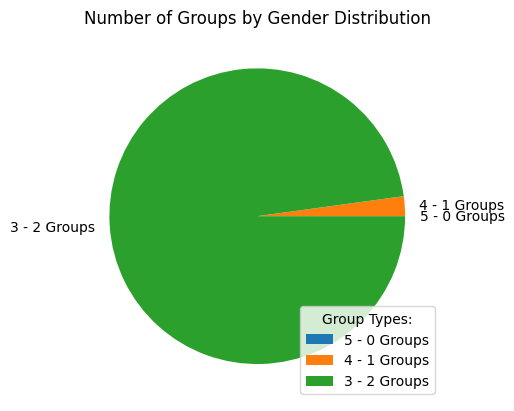

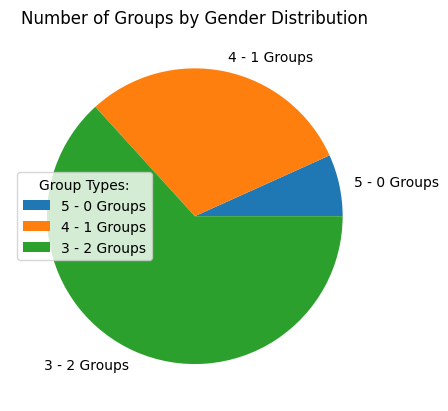

In [ ]:
def gender_pie_graph(data):
    import matplotlib.pyplot as plt

    y = gender_distribution(data)
    mylabels = ["5 - 0 Groups", "4 - 1 Groups", "3 - 2 Groups"]

    plt.pie(y, labels = mylabels)
    plt.title('Number of Groups by Gender Distribution')
    plt.legend(title = "Group Types:")
    plt.show()

gender_pie_graph(data_dict)
gender_pie_graph(random_data)

### Compare School Diversity ###
Sorted score = 99.3% -> Most of the teams have high school diversity score.
<details>
  <summary>Pseudocode:</summary>
  
 ```
FUNCTION overall_school_diversity(data):

    SET list_of_scores = empty_list

    // Loop through each Tuttorial Group
    FOR EACH tutorialGroup IN group_by_tg(data):
        
        SET list_of_tg_scores = empty_list

        // Loop through teams
        FOR i FROM 1 TO 10:
            
            // Calculate and store diversity score of the team
            SET team = Student ids in tutorialGroup WHERE student["Team Assigned"] IS i
            
            APPEND school_diversity(team, tutorialGroup) TO list_of_tg_scores
        END FOR

        // Calculate and store mean diversity score of the Tutorial Group
        SET avg_score_tg = SUM(list_of_tg_scores) / COUNT(list_of_tg_scores)
        APPEND avg_score_tg = list_of_scores
    END FOR

    // Calculate the Overall average diversity score from all groups
    SET overall_avg = SUM(list_of_scores) / COUNT(list_of_scores)
    
    RETURN overall_avg

END FUNCTION

```
</details>

And to print the result
 <details>
  <summary>Pseudocode:</summary>
  
 ```
// Calculate scores
SET random_score = overall_CGPA_mean_difference(random_data)
SET sorted_score = overall_CGPA_mean_difference(data_dict)

// Print scores
PRINT "Random score: " + random_score
PRINT "Sorted score: " + sorted_score

// Create the chart
SET labels = ['Random', 'Sorted']
SET values = [random_score, sorted_score]
CREATE BAR CHART (labels, values)
SET title = 'School Diversity Score Comparison'
SET X-Axis Label = 'Algorithm Type'
SET Y-Axis Label = 'Score'
SHOW CHART

```

In [ ]:
def overall_school_diversity(data):
    list_of_scores = []
    for tutorialGroup in group_by_tg(data):
        list_of_tg_scores = []

        for i in range(1,11):
            team = [id for id, student in tutorialGroup.items() if student["Team Assigned"] == i]
            list_of_tg_scores.append(school_diversity(team, tutorialGroup))

        avg_score_tg = sum(list_of_tg_scores)/len(list_of_tg_scores)

        list_of_scores.append(avg_score_tg)

    overall_avg = sum(list_of_scores)/len(list_of_scores)
    return overall_avg

Random score: 0.85
Sorted score: 0.993


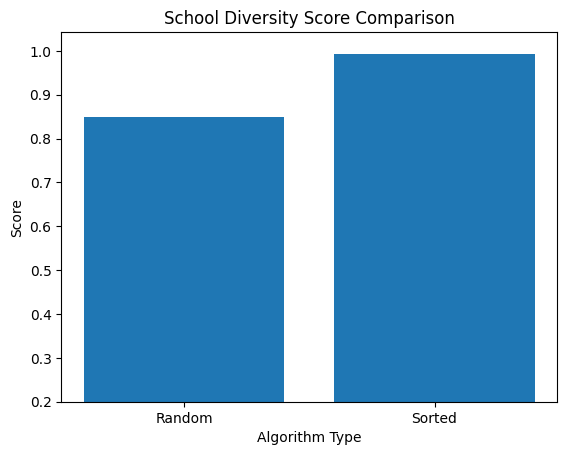

In [ ]:
import matplotlib.pyplot as plt

types = ['Random', 'Sorted']
score = [overall_school_diversity(random_data), overall_school_diversity(data_dict)]

plt.bar(types, score)
plt.title('School Diversity Score Comparison')
plt.xlabel('Algorithm Type')
plt.ylabel('Score')
plt.ylim(bottom=0.2) #Score cant be worse than 1/5

print(f"Random score: {overall_school_diversity(random_data)}\n"
      f"Sorted score: {overall_school_diversity(data_dict)}")

plt.show()

### Compare CGPA Diversity ###
To analyze the diversity of the CGPA, consider the average difference of the mean of each team to the mean of the tutorial group and the standard deviation(SD) to indicate of diversity.
* We are trying to make the difference of the mean from each team to be as low as possible.
* The SD needs to be higher since we need higher diversity for the groups



### Compare CGPA Diversity (Standard Deviation) ###
Higher standard deviation show teams are more diverse.
<details>
  <summary>Pseudocode:</summary>
  
 ```
FUNCTION overall_cgpa_sd(data):
    SET list_of_sd = empty_list

    // Loop through each TG
    FOR EACH tutorialGroup IN group_by_tg(data):
        
        SET list_of_tg_sd = empty_list

        // For each team
        FOR i FROM 1 TO 10:
            
            // Get CGPA scores for team i and team's SD
            SET team = CGPA values of students in tutorialGroup WHERE student["Team Assigned"] IS i
            
            APPEND calculateSD(team) TO list_of_tg_sd
        END FOR

        // Calulate SD for the Tutorial Group
        SET avg_sd_tg = SUM(list_of_tg_sd) / COUNT(list_of_tg_sd)

        APPEND avg_sd_tg TO list_of_sd
    END FOR

    // Calculate the overall average Standard Deviation
    SET overall_avg = SUM(list_of_sd) / COUNT(list_of_sd)
    
    RETURN overall_avg

END FUNCTION

```
</details>

And to print the result
 <details>
  <summary>Pseudocode:</summary>
  
 ```
// Calculate scores
SET random_score = overall_CGPA_mean_difference(random_data)
SET sorted_score = overall_CGPA_mean_difference(data_dict)

// Print scores
PRINT "Random score: " + random_score
PRINT "Sorted score: " + sorted_score

// Create the chart
SET labels = ['Random', 'Sorted']
SET values = [random_score, sorted_score]
CREATE BAR CHART (labels, values)
SET title = 'CGPA Standard Deviation Comparison'
SET X-Axis Label = 'Algorithm Type'
SET Y-Axis Label = 'Score'
SHOW CHART

```

In [ ]:
def overall_cgpa_sd(data):
    list_of_sd = []
    for tutorialGroup in group_by_tg(data):

        list_of_tg_sd = []

        for i in range(1,11):
            team = [student["CGPA"] for student in tutorialGroup.values() if student["Team Assigned"] == i]
            list_of_tg_sd.append(calculateSD(team))

        avg_sd_tg = sum(list_of_tg_sd)/len(list_of_tg_sd)

        list_of_sd.append(avg_sd_tg)

    overall_avg = sum(list_of_sd)/len(list_of_sd)
    return overall_avg


Random score: 0.09592154680810618
Sorted score: 0.1024131972051178


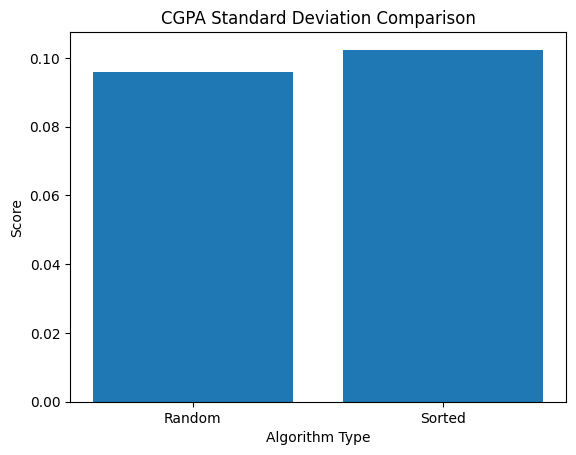

In [ ]:
import matplotlib.pyplot as plt

types = ['Random', 'Sorted']
score = [overall_cgpa_sd(random_data), overall_cgpa_sd(data_dict)]

plt.bar(types, score)
plt.title('CGPA Standard Deviation Comparison')
plt.xlabel('Algorithm Type')
plt.ylabel('Score')

print(f"Random score: {overall_cgpa_sd(random_data)}\n"
      f"Sorted score: {overall_cgpa_sd(data_dict)}")

plt.show()

### Compare CGPA Diversity (Mean) ###
Compare the absolute difference of the mean of each team to the mean of the tutorial group it is in. Smaller difference is better as it shows teams are more fair.
<details>
  <summary>Pseudocode:</summary>
  
 ```
FUNCTION overall_CGPA_mean_difference(data):
    SET list_of_diff = empty_list

    // Calculate the average difference of each Tutorial Group
    FOR EACH tutorialGroup IN group_by_tg(data):
        
        SET list_of_tg_diff = empty_list
        SET class_scores = CGPA values of all students in tutorialGroup
        SET class_avg = SUM(class_scores) / COUNT(class_scores)
        
        // Through each team
        FOR i FROM 1 TO 10:
            
            // Calculate the mean CGPA of team i
            SET team_scores = CGPA values of students in tutorialGroup WHERE "Team Assigned" IS i
            SET team_avg TO SUM(team_scores) / COUNT(team_scores)
            
            // Calculate and store the absolute difference of team i to the group
            SET diff TO ABS(team_avg - class_avg)
            APPEND diff TO list_of_tg_diff
        END FOR

        // Calculate the average difference of the teams to the mean of the group
        SET avg_diff_tg = SUM(list_of_tg_diff) / COUNT(list_of_tg_diff)
        
        // Add the Tutorial Group's result to the overall list
        APPEND avg_diff_tg TO list_of_diff
    END FOR

    // Calculate the Overall Mean Difference from all Tutorial Groups
    SET overall_diff = SUM(list_of_diff) / COUNT(list_of_diff)

    RETURN overall_diff

END FUNCTION

```
</details>

And to print the result
 <details>
  <summary>Pseudocode:</summary>
  
 ```
// Calculate scores
SET random_score = overall_CGPA_mean_difference(random_data)
SET sorted_score = overall_CGPA_mean_difference(data_dict)

// Print scores
PRINT "Random score: " + random_score
PRINT "Sorted score: " + sorted_score

// Create the chart
SET labels = ['Random', 'Sorted']
SET values = [random_score, sorted_score]
CREATE BAR CHART (labels, values)
SET title = 'CGPA Mean Difference Comparison'
SET X-Axis Label = 'Algorithm Type'
SET Y-Axis Label = 'Score'
SHOW CHART

```

In [ ]:
def overall_CGPA_mean_difference(data):
    list_of_diff = []
    for tutorialGroup in group_by_tg(data):
        list_of_tg_diff = []
        class_scores = [student["CGPA"] for student in tutorialGroup.values()]
        class_avg = sum(class_scores)/len(class_scores)

        for i in range(1,11):
            team_scores = [student["CGPA"] for student in tutorialGroup.values() if student["Team Assigned"] == i]
            team_avg = sum(team_scores)/len(team_scores)
            list_of_tg_diff.append(abs(team_avg - class_avg))

        avg_diff_tg = sum(list_of_tg_diff)/len(list_of_tg_diff)

        list_of_diff.append(avg_diff_tg)

    overall_diff = sum(list_of_diff)/len(list_of_diff)
    return overall_diff

Random score: 0.038579333333333334
Sorted score: 0.021812333333333343


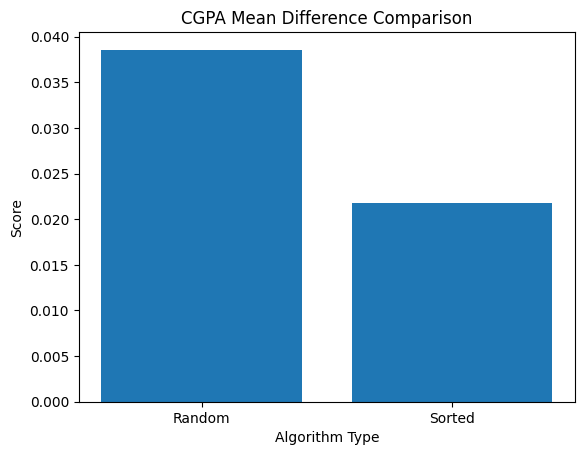

In [ ]:
import matplotlib.pyplot as plt

types = ['Random', 'Sorted']
score = [overall_CGPA_mean_difference(random_data), overall_CGPA_mean_difference(data_dict)]

plt.bar(types, score)
plt.title('CGPA Mean Difference Comparison')
plt.xlabel('Algorithm Type')
plt.ylabel('Score')

print(f"Random score: {overall_CGPA_mean_difference(random_data)}\n"
      f"Sorted score: {overall_CGPA_mean_difference(data_dict)}")

plt.show()